<h3> FGSM Adversarial Attack Against Intrusion Detection System </h3>

The problem statement is to evaluate the vulnerability of a neural network based intrusion detection system through Fast Gradient Sign Method (FGSM) adversarial attacks. The hypothesis is that the FGSM attack will be successful in for evading detection against the intrusion detection system, especially when the attack is optimized for attack success rate.


The python notebook will contain the methods of Training, Testing, and Evaluation of the Feedforward Neural Network that will be used as the IDS victim of the FGSM Attack Model. The FGSM attack model will be crafted and evaluated for error analysis from the victim and attacker perspective to show Proof of Concept.


<h3> Import Libraries </h3>

<h5> Make sure to import the following library dependencies before running any code to avoid errors.</h5>
Pandas
<br>Numpy
<br>Torch
<br>Sklearn
<br>Matplotlib


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

<h3> Load and Preprocess Train Dataset with Feature Engineering </h3>
This preprocessed dataset is then split into training and validation sets using train_test_split(X, y, test_size=0.2, random_state=42) in Cell 3, allocating 80% to X_train/y_train and 20% to X_val/y_val. The model is trained on X_train/y_train and validated on X_val/y_val during the 10 epochs. This ensures the validation set is separate from the training data used to fit the model.

In [2]:
# Load the data
data = pd.read_csv('cybersecurity_intrusion_data.csv')

# Preprocess the data
X = data.drop(['attack_detected'], axis=1)
y = data['attack_detected']

# Drop the session_id column
X = X.drop('session_id', axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['protocol_type', 'encryption_used', 'browser_type'])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Feature engineering
X['login_attempt_rate'] = X['login_attempts'] / X['session_duration']
X['failed_login_ratio'] = X['failed_logins'] / (X['login_attempts'] + 1)

# Scale new features
X[['login_attempt_rate', 'failed_login_ratio']] = scaler.fit_transform(X[['login_attempt_rate', 'failed_login_ratio']])

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure all columns are numerical
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_train = X_train.dropna()
y_train = y_train[X_train.index]


<h3> Define the Intrusion Detection Model</h3>

The model defines a simple feedforward neural network using PyTorch for binary classification. The model, named Net, consists of three fully connected layers with ReLU activation functions, designed to map an input feature vector to a two-dimensional output representing class probabilities. Trained using cross-entropy loss and the Adam optimizer, this basic multi-layer perceptron learns to classify data into one of two categories based on the input features. The model takes the amount of features as input_dim

In [3]:
# Define the dataset class
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        X = X.copy()
        X[['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
           'encryption_used_AES', 'encryption_used_DES',
           'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
           'browser_type_Safari', 'browser_type_Unknown']] = X[['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
           'encryption_used_AES', 'encryption_used_DES',
           'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
           'browser_type_Safari', 'browser_type_Unknown']].astype(float)
        self.X = torch.tensor(X.values, dtype=torch.float32)
        if isinstance(y, pd.Series):
            self.y = torch.tensor(y.values, dtype=torch.long)
        else:
            self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        return X, y

# Define the model
class Net(nn.Module):
    def __init__(self, input_dim):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model with correct input dimension
model = Net(input_dim=X_train.shape[1])

<h3> Train the Intrusion Detection Model</h3>

This trains the defined neural network model using the Adam optimizer and cross-entropy loss over 10 epochs, evaluating its performance on a validation set after each epoch. The training loop iterates through batches of the training data, calculates the loss, performs backpropagation, and updates the model's weights, while the evaluation step computes the accuracy on the validation set to monitor the model's learning progress.

In [4]:
# Train model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = Dataset(X_train, y_train)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(10):
    model.train()
    total_loss = 0
    for X_batch, y_batch in data_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {total_loss / len(data_loader)}')

    def convert_bool_to_float(X):
        bool_cols = ['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
                     'encryption_used_AES', 'encryption_used_DES',
                     'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
                     'browser_type_Safari', 'browser_type_Unknown']
        X[bool_cols] = X[bool_cols].astype(float)
        return X

    X_val = convert_bool_to_float(X_val)

    model.eval()
    with torch.no_grad():
        outputs = model(torch.tensor(X_val.values, dtype=torch.float32))
        _, predicted = torch.max(outputs, 1)
        accuracy = accuracy_score(y_val.values, predicted.numpy())
        print(f'Epoch {epoch+1}, Accuracy: {accuracy:.4f}')


Epoch 1, Loss: 0.4693219983428093
Epoch 1, Accuracy: 0.8569
Epoch 2, Loss: 0.35761713239687754
Epoch 2, Accuracy: 0.8753
Epoch 3, Loss: 0.32889114781653034
Epoch 3, Accuracy: 0.8836
Epoch 4, Loss: 0.3113116310854836
Epoch 4, Accuracy: 0.8721
Epoch 5, Loss: 0.3057081477100879
Epoch 5, Accuracy: 0.8779
Epoch 6, Loss: 0.3002216354885361
Epoch 6, Accuracy: 0.8863
Epoch 7, Loss: 0.2996529581407124
Epoch 7, Accuracy: 0.8842
Epoch 8, Loss: 0.29526298552377456
Epoch 8, Accuracy: 0.8774
Epoch 9, Loss: 0.2912298815956176
Epoch 9, Accuracy: 0.8889
Epoch 10, Loss: 0.2894658867472385
Epoch 10, Accuracy: 0.8905


The output shows your model improving accuracy over 10 epochs, with loss dropping, reflecting effective training.

<h3> Load and Preprocess Test Data with Feature Engineering </h3>
The second train_test_split here creates a new test set (X_test/y_test) that is distinct from the initial X_val used for validation. Although both splits use the same random_state=42, the reprocessing and resplitting ensure X_test is a fresh 20% sample from the reloaded dataset, not overlapping with the training or validation data from the first split.
The Feature Engineering focuses on login_attempt_rate, login_attempts, session_duration, failed_login_ratio, failed_logins, and login_attempts.

In [5]:
# Load the data
data = pd.read_csv('cybersecurity_intrusion_data.csv')

# Preprocess the data
X = data.drop(['attack_detected'], axis=1)
y = data['attack_detected']

# Drop the session_id column
X = X.drop('session_id', axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['protocol_type', 'encryption_used', 'browser_type'])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Feature engineering
X['login_attempt_rate'] = X['login_attempts'] / X['session_duration']
X['failed_login_ratio'] = X['failed_logins'] / (X['login_attempts'] + 1)

# Scale new features
X[['login_attempt_rate', 'failed_login_ratio']] = scaler.fit_transform(X[['login_attempt_rate', 'failed_login_ratio']])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure all columns are numerical
X_test = X_test[X_train.columns]
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_test = X_test.fillna(0)

<h3> Evaluate the Intrusion Detection Model on Test Data </h3>
<br> The evaluation of the intrusion detection model for "Model Accuracy on Test Data" is performed by preparing the X_test DataFrame with boolean-to-float conversion, setting the model to evaluation mode with model.eval(), and loading the test data into a single batch using DataLoader. Within a torch.no_grad() context, the model generates predictions from X_batch, and torch.max determines the predicted class labels. The accuracy is calculated by comparing these predictions to the true labels (y_batch), computing the proportion of correct predictions ((predicted == y_batch).sum().item() / len(y_batch)), and the result is printed as "Model Accuracy on Test Data."

In [6]:
# Assuming X_test is a pandas DataFrame before conversion to numpy array
X_test = pd.DataFrame(X_test, columns=X_train.columns)

# Define a function to convert boolean columns to float
def convert_bool_to_float(X):
    bool_cols = ['protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP',
                 'encryption_used_AES', 'encryption_used_DES',
                 'browser_type_Chrome', 'browser_type_Edge', 'browser_type_Firefox',
                 'browser_type_Safari', 'browser_type_Unknown']
    X[bool_cols] = X[bool_cols].astype(float)
    return X

# Convert boolean columns to float
X_test = convert_bool_to_float(X_test)

# Evaluate the model on test data
model.eval()
test_dataset = Dataset(X_test, y_test[X_test.index])
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(X_test), shuffle=False)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_batch).sum().item() / len(y_batch)
        print(f'Model Accuracy on Test Data: {accuracy:.4f}')

Model Accuracy on Test Data: 0.8905


The output Model Accuracy on Test Data: 0.8863 indicates your model correctly classifies 88.63% of test samples, suggesting good training and feature engineering

<h3>Receiver Operating Characteristic (ROC) Curve Baseline Model</h3>
The ROC curve plot is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at different thresholds. It's a way to measure how well a model can distinguish between two things, like "yes" or "no", "true" or "false".

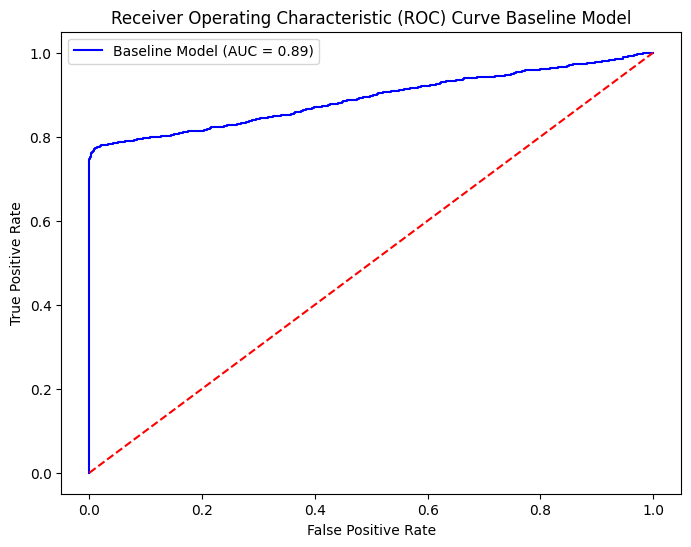

In [7]:
# Convert the DataFrame to a PyTorch tensor
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# Predict probabilities for the test set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    y_pred = torch.nn.functional.softmax(outputs, dim=1)[:, 1]  # Get the probability of the positive class

# Plot ROC curve for the baseline model
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_pred.cpu().numpy())
auc_baseline = auc(fpr_baseline, tpr_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_baseline, tpr_baseline, color='blue', label=f'Baseline Model (AUC = {auc_baseline:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Baseline Model')
plt.legend()
plt.show()

The ROC curve shows the relationship between the True Positive Rate (TPR) and the False Positive Rate (FPR) at different thresholds. A good model should have a high TPR and a low FPR.
In this case, the AUC (Area Under the Curve) is 0.89, which indicates that the model has good performance. The curve is also close to the top-left corner of the plot, which means that the model is able to correctly classify most of the positive instances while minimizing false positives.

<h3> Define FGSM Attack Model </h3>
Fast Gradient Sign Method (FGSM) is an adversarial attack technique used in machine learning to generate adversarial examples by introducing small, controlled perturbations to input data, causing misclassification by models like neural network


In [8]:
# FGSM attack
def fgsm_attack(model, x, y, epsilon=0.1):
    x.requires_grad = True
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    gradient = x.grad.sign()
    x_adv = x + epsilon * gradient
    return x_adv

The code implements the FGSM attack by enabling gradient tracking on input x, computing the loss with criterion between model predictions and true labels y, backpropagating to get the gradient’s sign, and adding a perturbation scaled by epsilon to create an adversarial example x_adv, returned for robustness testing.

<h3> Evaluate FGSM Attack Model </h3>
This code evaluates how vulnerable a machine learning model is to adversarial attacks using the Fast Gradient Sign Method (FGSM). It does so by iterating through multiple values of ε (epsilon), which controls the intensity of the attack. For each epsilon, the code generates adversarial examples using the fgsm_attack function and then feeds them to the model. It calculates how accurate the model is on these manipulated inputs and stores the results. Additionally, it computes two important metrics: the attack success rate, which measures how often the adversarial input changes the model’s prediction, and the false negative rate, which tracks how often the model wrongly classifies an attack as benign. These metrics help assess how well the model holds up under different levels of adversarial pressure.



In [9]:
# Evaluate FGSM attack
epsilon_values = [0.1, 0.2, 0.3, 0.4, 0.5]
accuracies = []
model.eval()
with torch.no_grad():
    outputs = model(torch.tensor(X_test.values, dtype=torch.float32))
    _, y_pred = torch.max(outputs, 1)

for epsilon in epsilon_values:
    x_adv = fgsm_attack(model, torch.tensor(X_test.values, dtype=torch.float32).requires_grad_(True), torch.tensor(y_test.values, dtype=torch.long), epsilon)
    outputs_adv = model(x_adv)
    y_pred_adv = torch.argmax(outputs_adv, dim=1)
    accuracy_adv = accuracy_score(y_test, y_pred_adv.detach().numpy())
    accuracies.append(accuracy_adv)
    print(f'Epsilon: {epsilon}, Accuracy on Adversarial Examples: {accuracy_adv:.2f}')

    # Calculate attack success rate and false negative rate
    attack_success_rate = np.mean((y_pred.numpy() != y_pred_adv.detach().numpy()).astype(int))
    false_negative_rate = np.mean(((y_test.values == 1) & (y_pred_adv.detach().numpy() == 0)).astype(int))
    print(f'Attack Success Rate: {attack_success_rate:.2f}, False Negative Rate: {false_negative_rate:.2f}')

Epsilon: 0.1, Accuracy on Adversarial Examples: 0.73
Attack Success Rate: 0.16, False Negative Rate: 0.20
Epsilon: 0.2, Accuracy on Adversarial Examples: 0.51
Attack Success Rate: 0.38, False Negative Rate: 0.35
Epsilon: 0.3, Accuracy on Adversarial Examples: 0.37
Attack Success Rate: 0.52, False Negative Rate: 0.39
Epsilon: 0.4, Accuracy on Adversarial Examples: 0.30
Attack Success Rate: 0.59, False Negative Rate: 0.41
Epsilon: 0.5, Accuracy on Adversarial Examples: 0.23
Attack Success Rate: 0.66, False Negative Rate: 0.42


<h3> Here's a breakdown of the results: </h3>
Accuracy on Adversarial Examples: As epsilon increases, the accuracy of the model on the adversarial examples decreases. This is expected, as larger values of epsilon result in more significant perturbations to the input data, making it more difficult for the model to classify correctly.

<br>Attack Success Rate: The attack success rate increases as epsilon increases. This indicates that the FGSM attack is more effective at generating adversarial examples that can fool the model when epsilon is larger.
<br>False Negative Rate: The false negative rate also increases as epsilon increases. This suggests that the model is more likely to misclassify actual attacks as non-attacks when the adversarial examples are generated with larger values of epsilon.

<h3> Accuracy vs Epsilon </h3>
This is the Accuracy of the model in predicting Intrusion Detection data vs Epsilon,  which represents the magnitude or intensity of the perturbation added to the original input.


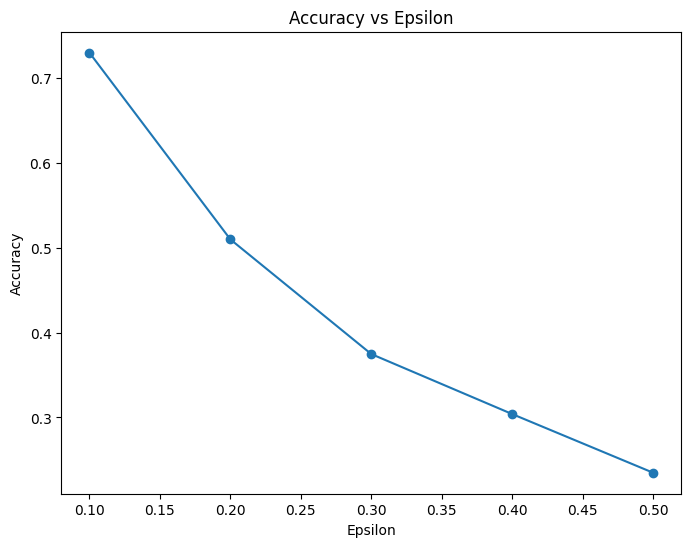

In [17]:
# Accuracy vs Epsilon plot
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies, marker='o')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon')
plt.show()

The Accuracy vs Epsilon plot suggests that the model is vulnerable to adversarial attacks, as increasing the epsilon value leads to a decrease in accuracy.
The rate of decrease in accuracy can be used to evaluate the robustness of the model against adversarial attacks.

<h3> Attack Success vs Epsilon</h3>
The Attack Success Rate is the inverse of the models accuracy. This is metric from the attacker perspective. We expect the Attack Success Rate to increase as Epsilon value increases.

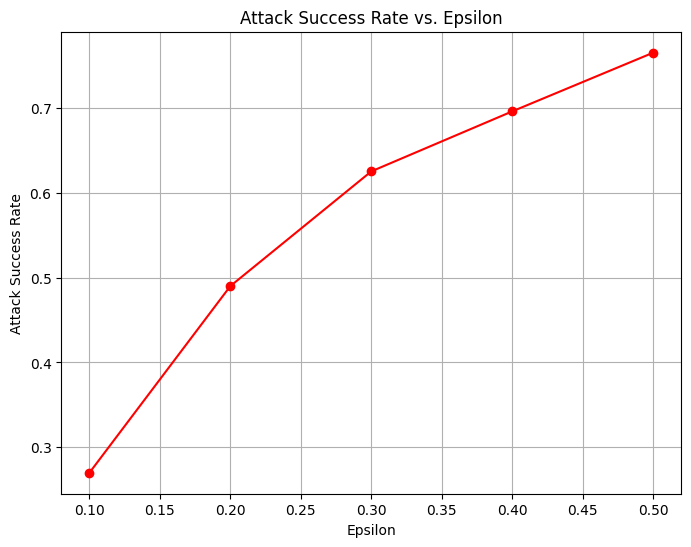

In [15]:
# Plotting Attack Success Rate vs. Epsilon
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, [1-x for x in accuracies], marker='o', linestyle='-', color='red')
plt.title('Attack Success Rate vs. Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Attack Success Rate')
plt.grid(True)
plt.show()


<h3>Receiver Operating Characteristic (ROC) Curve after FGSM Attack</h3>
The ROC Curve suggests that as the epsilon value increases, the model's performance decreases, indicating that the FGSM attack is more effective at higher epsilon values. The AUC values also decrease as the epsilon value increases, indicating a decline in the model's ability to distinguish between positive and negative classes.

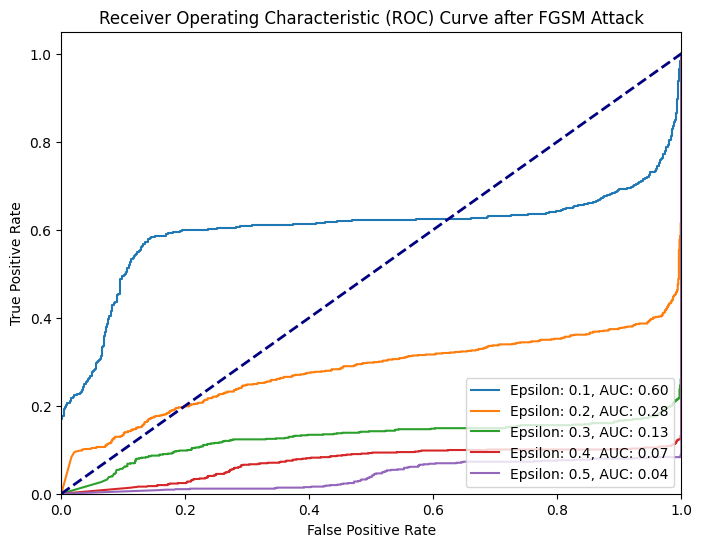

In [16]:
# Plot ROC curves for different epsilon values
aucs = []
plt.figure(figsize=(8, 6))
for i, epsilon in enumerate(epsilon_values):
    x_adv = fgsm_attack(model, torch.tensor(X_test.values, dtype=torch.float32).requires_grad_(True), torch.tensor(y_test.values, dtype=torch.long), epsilon)
    outputs_adv = model(x_adv)
    y_pred_proba_adv = torch.softmax(outputs_adv, dim=1)[:, 1].detach().numpy()
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_adv)
    auc_value = auc(fpr, tpr)
    aucs.append(auc_value)
    plt.plot(fpr, tpr, label=f'Epsilon: {epsilon}, AUC: {auc_value:.2f}')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve after FGSM Attack')
plt.legend(loc="lower right")
plt.show()

This suggests that the FGSM attack has significantly compromised the model's performance, making it worse than random guessing. The attack has likely generated adversarial examples that are able to fool the model, resulting in a high false positive rate and a low true positive rate.



<H3> Mitigation Techniques</h3>
Mitigating the Fast Gradient Sign Method (FGSM) and similar adversarial attacks involves techniques that improve a model’s robustness against small, intentionally crafted perturbations. Here are the most effective mitigations:


<h5> Adversarial Training (Most Effective)</h5>
Why: Trains the model on both clean and FGSM-generated examples, directly improving robustness.
<br> Pros: Proven to significantly increase resistance to FGSM and related attacks.
<br> Cons: Slows training and may reduce clean accuracy slightly.
<br> When to use: Always, if defense against adversarial examples is a priority.

<h5> Input Preprocessing (Feature Squeezing, JPEG Compression) </h5>
Why: Disrupts small perturbations before the model processes them.
<br> Pros: Easy to implement; works as a plug-in step.
<br> Cons: Can reduce accuracy on legitimate inputs; not foolproof alone.
<br> When to use: As a lightweight defense or in combination with others.

<h5>Robust Architectures with Regularization </h5>
Why: Some models and training regimes are naturally more robust (dropout, weight decay, or robust loss functions).
<br> Pros: Improves general robustness and can reduce overfitting.
<br> Cons: Not sufficient against strong attacks by itself.
<br> When to use: As a foundation; combine with adversarial training for best results.


<h3> Conclusion Notes </h3>
This baseline neural network victim model was designed to first establish a functional pipeline and understand the model's performance without additional constraints.

<br>Implicit regularization methods were used such as 10 fixed training epochs, limited model capacity for two hidden layers 128/64, mini batch training size 32, data normalization, and feature engineering were used.

<br>The absence of calling explicit regularization techniques like L2 weight decay or dropout to improve generalization were not needed to penalize the model complexity and overfitting and still allow us to see clearly see how the FGSM attack can be most effective in an attack.

<br>The proofs of concept show how increasing perturbations of epsilon value via the deployment of the FGSM attack decrease the victim model accuracy and demonstrate the dangers of attack and the manipulation of outputs from ML models.